Zadanie 11

Dataset: Sprzedaż 6 produktów w 30 dni

sales = np.random.randint(50, 200, size=(6, 30))

Oblicz:
- Trend sprzedaży per produkt (różnica między ostatnimi 7 dniami a pierwszymi 7 dniami)
- Najlepszy tydzień (dni 0-6, 7-13, 14-20, 21-27) dla całej sprzedaży
- Wykres: sprzedaż per produkt w czasie (linie)

Wymagania:
- Użyj slicingu do wycinania tygodni
- Wizualizacja matplotlib

Sprzedaż 6 produktów w 30 dni

[[ 83 184  62 148 138 113 111 115  68 168  65 114 134 164  86  60  88  94
   51  92  64 107 147 139 106 164 185  90 181 144]
 [194 109 128 172  59 146 126 135 134 178  72 102 115 159 199 171 104  95
  147 147 150  64 130  66 128  59 176  85  95 151]
 [168  59 113  78  94  60 199 169  97  63  98  67  59 147  73 123 151  78
  106  94 197  99 107 165 139  71 125  67  60 182]
 [166 111 198 125 166 136 142  69 110 112  81 165 104 130 141 104 181  63
  153  56 198  77 118 142 198 194  97  67  62 136]
 [110  65  74 119 137 177  75 178 187 180 178 117 103 144  57 119  64  96
  165  70 162 144  64  97 127  58 189 142 161 182]
 [166 198 160  68  91 102 191 199 121 127 154 175 154 108  68 163 142 188
  186  63 102  60  59 149 179 192 170 184 176  91]]



Suma sprzedaży 6 produktów w pierwszych 7 dniach:
 [ 839  934  771 1044  757  976]

Suma sprzedaży 6 produktów w ostatnich 7 dniach:
 [1009  760  809  896  956 1141]

Trend sprzedaży: [ 170 -174   38 -148  199  165]

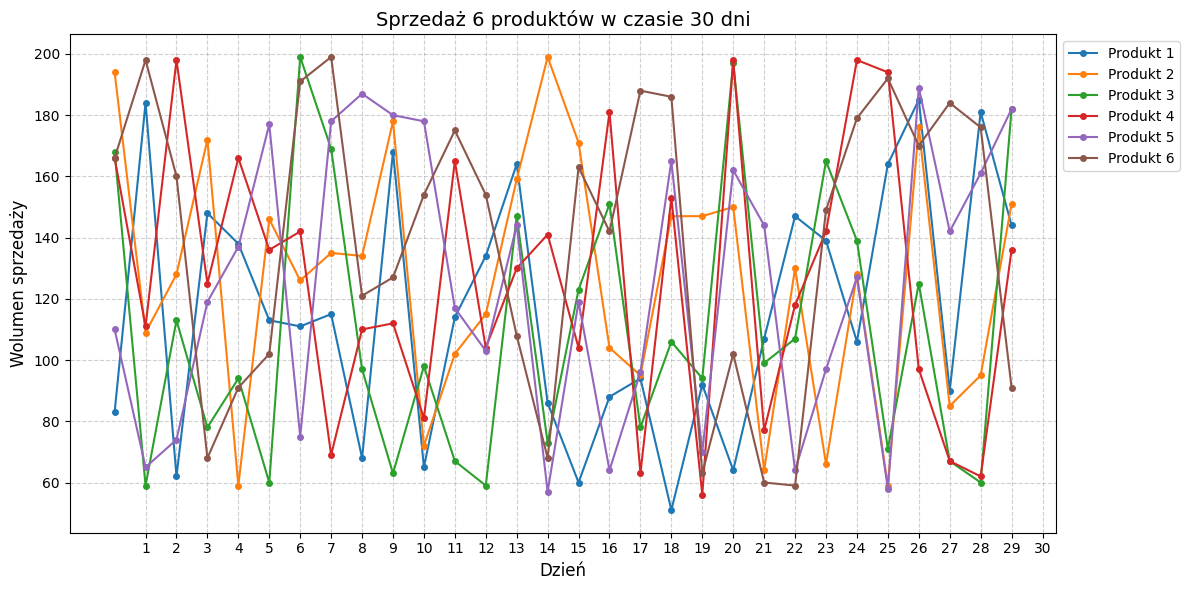

In [60]:
import numpy as np
import matplotlib.pyplot as plt

sales = np.random.randint(50, 200, size=(6, 30))

print("Sprzedaż 6 produktów w 30 dni\n")
print(sales)

print("\n")
suma_sprzedazy_z_pierwszych_7_dni = np.sum(sales[:,:7], axis=1)
suma_sprzedazy_z_ostatnich_7_dni = np.sum(sales[:,-7:], axis=1)
trend_sprzedazy = suma_sprzedazy_z_ostatnich_7_dni - suma_sprzedazy_z_pierwszych_7_dni
print()
print(f"Suma sprzedaży 6 produktów w pierwszych 7 dniach:\n {suma_sprzedazy_z_pierwszych_7_dni}")
print()
print(f"Suma sprzedaży 6 produktów w ostatnich 7 dniach:\n {suma_sprzedazy_z_ostatnich_7_dni}")
print()
print("Trend sprzedaży:", trend_sprzedazy)
print()
print("Sprzedaż produktów")
print(f"{'Produkt'}{' ':<5}{'Pierwsze 7 dni'}{' ':<5}{'Ostatnie 7 dni'}{' ':<5}{'Trend'}")
print("-"*55)
for identyfikator_produktu, (pierwsze_7_dni, ostatnie_7_dni, trend) in enumerate(zip(suma_sprzedazy_z_pierwszych_7_dni, suma_sprzedazy_z_ostatnich_7_dni, trend_sprzedazy)):
    print(f"{(identyfikator_produktu + 1):<7}{' ':<5}{pierwsze_7_dni:<14}{' ':<5}{ostatnie_7_dni:<14}{' ':<5}{trend:<5}")
    print("-"*55)

suma_sprzedazy_wszystkich_produktow = sales.sum(axis=0)
tygodnie_sprzedazy = suma_sprzedazy_wszystkich_produktow[:28].reshape(4, 7) # 4 tygodnie x 7 dni
tygodniowe_sumy_sprzedazy = tygodnie_sprzedazy.sum(axis=1)
tygodnie_sprzedazy_przedzialy = [
    "Dni 0-6",
    "Dni 7-13",
    "Dni 14-20",
    "Dni 21-27"
]

najlepszy_tydzien_indeks = np.argmax(tygodniowe_sumy_sprzedazy)

print(f"\nSuma sprzedaży w tygodniach: {tygodniowe_sumy_sprzedazy}")
print(f"Najlepszy tydzień sprzedaży to: Tydzień nr {najlepszy_tydzien_indeks + 1} ({tygodnie_sprzedazy_przedzialy[najlepszy_tydzien_indeks]})")
print(f"Sprzedaż w najlepszym tygodniu: {tygodniowe_sumy_sprzedazy[najlepszy_tydzien_indeks]}")

# Wizualizacja
plt.figure(figsize=(12, 6))

for i in range(sales.shape[0]):
    plt.plot(sales[i], marker='o', markersize=4, label=f'Produkt {i+1}')

plt.title('Sprzedaż 6 produktów w czasie 30 dni', fontsize=14)
plt.xlabel('Dzień', fontsize=12)
plt.ylabel('Wolumen sprzedaży', fontsize=12)
plt.xticks(range(1, 31))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.show()